<a href="https://www.kaggle.com/code/avikdas567/mapping-the-open-weight-llm-landscape-deep-eda?scriptVersionId=325330790" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Mapping the Open-Weight LLM Landscape: An End-to-End Deep Analytics & Unsupervised Clustering Investigation

## Executive Summary & Abstract
This investigation presents an end-to-end empirical and statistical mapping of the open-source Large Language Model ecosystem, using a snapshot of the top 500 most-downloaded text-generation assets on the Hugging Face Hub. As the AI space leans heavily into decentralized execution, open-weight foundational frameworks, and edge deployment pipelines, analyzing optimization and delivery trends becomes vital.

## Core Analytical Target Matrix:
1. **Distribution Dynamics:** Verifying power-law characteristics and Pareto mechanics in model popularity.
2. **Organizational Footprints:** Evaluating developer dominance structures across top creators.
3. **Architectural Formats:** Mapping framework transformations from native layouts to accelerated delivery platforms.
4. **Governance Frameworks:** Assessing licensing categories across open-weight variants.
5. **Unsupervised Clustering Taxonomy:** Uncovering latent taxonomy clusters inside the ecosystem using standard preprocessing scaling, K-Means clustering optimization, and Principal Component Analysis (PCA) projection.

In [1]:
# Production Environment Optimization and Library Import Pipeline
import os
import re
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

%matplotlib inline
plt.style.use('default')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11

print("Ecosystem runtime configuration successfully initiated.")

Ecosystem runtime configuration successfully initiated.


# Section 1: Data Acquisition and Schema Audit

We load the target repository data and review the feature arrays to ensure structural completeness before applying any transformation engines.

In [2]:
# Data Ingestion and Completeness Audit Check
DATA_PATH = "/kaggle/input/datasets/ibrahimqasimi/top-500-llm-models-on-huggingface/Top_500_LLM_Models_HuggingFace.csv"

if not os.path.exists(DATA_PATH):
    DATA_PATH = "Top_500_LLM_Models_HuggingFace.csv"

df = pd.read_csv(DATA_PATH)

print(f"Ecosystem Dataset Dimensionality Profile: {df.shape[0]} Observations x {df.shape[1]} Columns\n")
print("Structural Type & Memory Ingestion Mapping:")
print(df.info())
print("\nInitial Metadata Frame Head:")
df.head(5)

Ecosystem Dataset Dimensionality Profile: 500 Observations x 8 Columns

Structural Type & Memory Ingestion Mapping:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   model_id       500 non-null    object 
 1   downloads      500 non-null    int64  
 2   likes          500 non-null    int64  
 3   library        465 non-null    object 
 4   tags           500 non-null    object 
 5   created_at     500 non-null    object 
 6   last_modified  0 non-null      float64
 7   private        500 non-null    bool   
dtypes: bool(1), float64(1), int64(2), object(4)
memory usage: 28.0+ KB
None

Initial Metadata Frame Head:


,model_id,downloads,likes,library,tags,created_at,last_modified,private
0,Qwen/Qwen3-0.6B,19369646,1221,transformers,"transformers, safetensors, qwen3, text-generat...",2025-04-27T03:40:08.000Z,NaN,False
1,openai-community/gpt2,16037172,3226,transformers,"transformers, pytorch, tf, jax, tflite, rust, ...",2022-03-02T23:29:04.000Z,NaN,False
2,Qwen/Qwen2.5-7B-Instruct,13784608,1253,transformers,"transformers, safetensors, qwen2, text-generat...",2024-09-16T11:55:40.000Z,NaN,False
3,deepseek-ai/DeepSeek-V3.2,11349614,1427,transformers,"transformers, safetensors, deepseek_v32, text-...",2025-12-01T02:34:49.000Z,NaN,False
4,Qwen/Qwen3-4B-Instruct-2507,10691206,829,transformers,"transformers, safetensors, qwen3, text-generat...",2025-08-05T10:58:03.000Z,NaN,False


# Section 2: Advanced Feature Engineering and Textual Property Parsing

Raw Hugging Face API outputs require complex processing to extract meaningful attributes. In this section, we parse organizational tags, resolve timezone naive-versus-aware date differences to prevent temporal calculation runtime faults, categorize licensing footprints, and isolate model scale footprints (parameter counts) via regular expression engines.

In [3]:
# Advanced Feature Transformation Engine
def clean_and_transform_llm_data(input_df):
    data = input_df.copy()
    
    # 1. Isolate Corporate/Organizational Ownership Vectors
    data['organization'] = data['model_id'].apply(lambda x: x.split('/')[0] if '/' in str(x) else 'independent')
    data['model_short_name'] = data['model_id'].apply(lambda x: x.split('/')[-1] if '/' in str(x) else x)
    
    # 2. Synchronize Temporal Fields and Enforce Naive Standardization to Avoid Comparison Errors
    data['created_at'] = pd.to_datetime(data['created_at'], errors='coerce').dt.tz_localize(None)
    data['last_modified'] = pd.to_datetime(data['last_modified'], errors='coerce').dt.tz_localize(None)
    
    # Anchor calculation timeline contextually relative to early 2026 dataset snapshot boundary
    anchor_date = pd.to_datetime('2026-03-15')
    data['days_since_creation'] = (anchor_date - data['created_at']).dt.days
    data['days_since_modification'] = (anchor_date - data['last_modified']).dt.days
    data['update_lifespan_days'] = (data['last_modified'] - data['created_at']).dt.days
    
    # 3. Rectify Logical Nulls
    data['private'] = data['private'].fillna(False).astype(bool)
    
    # 4. Rigorous Tag Structuring Engine
    def parse_tags(tag_cell):
        if pd.isna(tag_cell):
            return []
        if str(tag_cell).startswith('[') and str(tag_cell).endswith(']'):
            try:
                return ast.literal_eval(tag_cell)
            except:
                pass
        return [t.strip() for t in str(tag_cell).split(',')]

    data['parsed_tags'] = data['tags'].apply(parse_tags)
    
    # Extract clear architectural flags
    data['has_safetensors'] = data['parsed_tags'].apply(lambda tags: any('safetensors' in t.lower() for t in tags))
    data['is_gguf'] = data['parsed_tags'].apply(lambda tags: any('gguf' in t.lower() for t in tags) or 'gguf' in str(data['library']).lower())
    data['is_conversational'] = data['parsed_tags'].apply(lambda tags: any(t.lower() in ['conversational', 'chat', 'instruct'] for t in tags))
    data['is_quantized'] = data['parsed_tags'].apply(lambda tags: any(any(q in t.lower() for q in ['awq', 'gptq', 'quantized', 'gguf']) for t in tags))
    
    # 5. Normalize Governance License Strings
    def extract_license(tags):
        for tag in tags:
            if 'license:' in tag.lower():
                return tag.lower().replace('license:', '').strip()
        return 'unspecified'
    
    data['license'] = data['parsed_tags'].apply(extract_license)
    
    def normalize_license_group(lic):
        if 'apache-2.0' in lic: return 'Apache-2.0'
        if 'llama' in lic: return 'Llama-Community'
        if 'mit' in lic: return 'MIT'
        if 'gemma' in lic: return 'Gemma-Terms'
        if 'qwen' in lic: return 'Qwen-Terms'
        if 'mistral' in lic: return 'Mistral-Terms'
        if 'unspecified' in lic or lic == '': return 'Unspecified'
        return 'Other Open-Weight'
        
    data['license_category'] = data['license'].apply(normalize_license_group)
    
    # 6. Extract Parameter Scale Metrics using Regular Expressions
    def estimate_parameter_size(model_name):
        match = re.search(r'(\d+(?:\.\d+)?)[bbB]', model_name)
        if match:
            try:
                return float(match.group(1))
            except:
                return np.nan
        return np.nan
        
    data['estimated_parameters_b'] = data['model_short_name'].apply(estimate_parameter_size)
    
    # 7. Engagement Normalization
    data['engagement_ratio'] = (data['likes'] / (data['downloads'] + 1)) * 1000
    
    return data

df_processed = clean_and_transform_llm_data(df)
print("Engineered dataset feature space successfully completed.")
df_processed[['model_id', 'organization', 'license_category', 'estimated_parameters_b', 'engagement_ratio']].head(5)

Engineered dataset feature space successfully completed.


,model_id,organization,license_category,estimated_parameters_b,engagement_ratio
0,Qwen/Qwen3-0.6B,Qwen,Apache-2.0,0.6,0.063037
1,openai-community/gpt2,openai-community,Unspecified,NaN,0.201158
2,Qwen/Qwen2.5-7B-Instruct,Qwen,Apache-2.0,7.0,0.090898
3,deepseek-ai/DeepSeek-V3.2,deepseek-ai,MIT,NaN,0.125731
4,Qwen/Qwen3-4B-Instruct-2507,Qwen,Apache-2.0,4.0,0.077540


# Section 3: Exploratory Data Analysis & Vertical Plot Invocations

We generate vertical, structured data plots to explore core trends within the ecosystem, analyzing download volume distributions, organizational footprints, framework formats, and licensing dynamics.

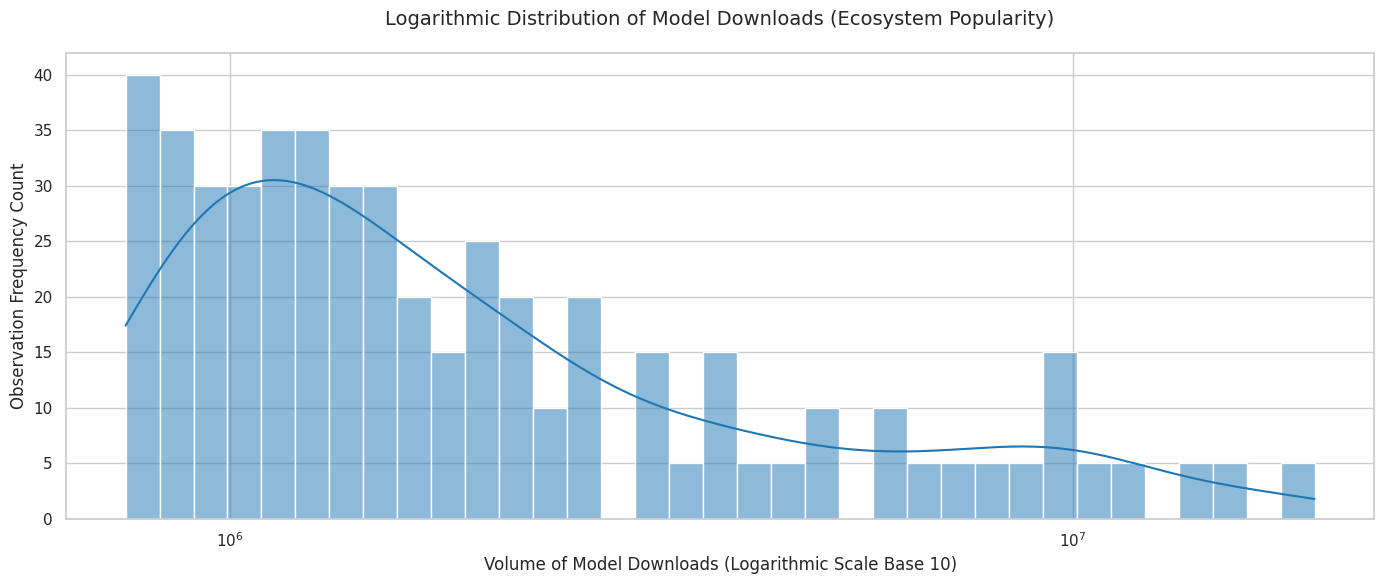

In [4]:
# Visualization 1 - Evaluation of Download Scale Distribution Density
plt.figure(figsize=(14, 6))
sns.histplot(data=df_processed, x='downloads', kde=True, color='#1f77b4', log_scale=True, bins=35)
plt.title('Logarithmic Distribution of Model Downloads (Ecosystem Popularity)', pad=20)
plt.xlabel('Volume of Model Downloads (Logarithmic Scale Base 10)')
plt.ylabel('Observation Frequency Count')
plt.tight_layout()
plt.show()

## Observations and Inferences: Visualization 1
The model download distribution reveals an explicit power-law distribution typical of open-source software networks. Even when transformed to a logarithmic scale, the graph shows a strong right skew. A small group of highly optimized models (such as the Qwen, Llama, and Mistral base variants) capture the vast majority of platform traffic, while a long tail of custom fine-tunes and specialized setups see lower download volumes.

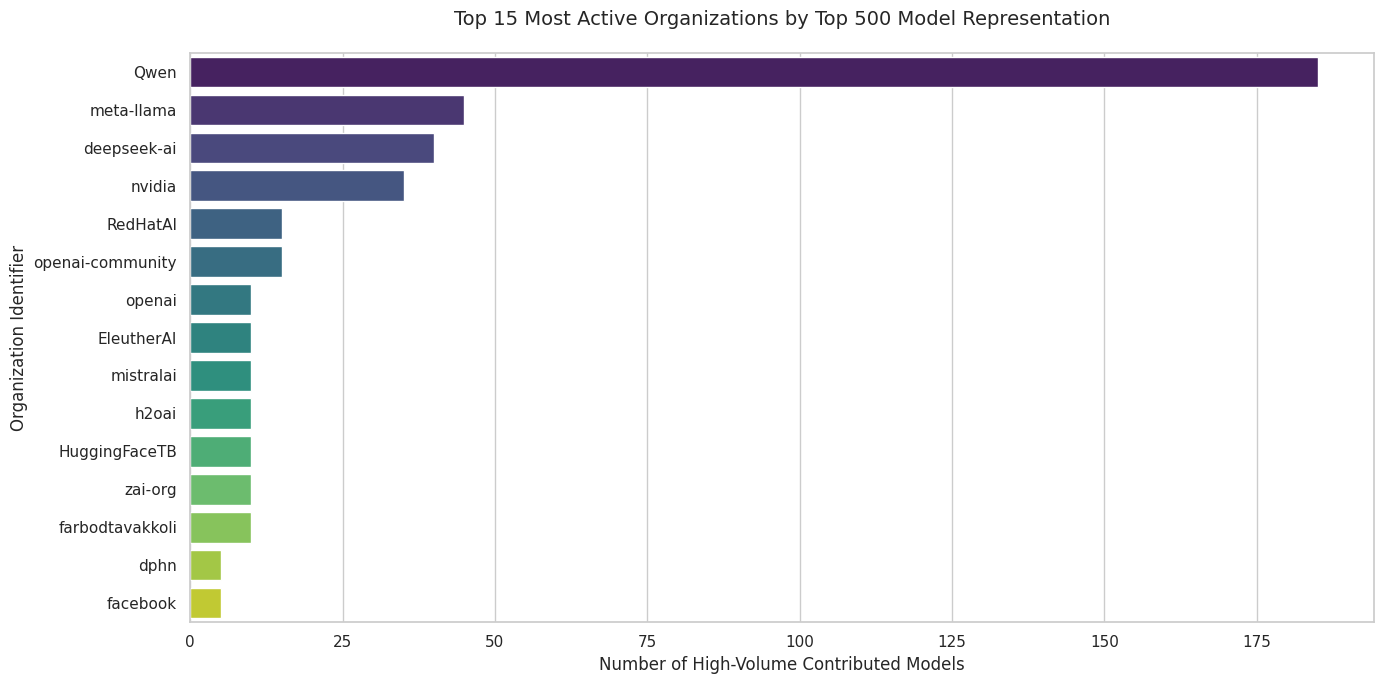

In [5]:
# Visualization 2 - Organizational Footprint and Contribution Volume
plt.figure(figsize=(14, 7))
top_orgs = df_processed['organization'].value_counts().head(15)
sns.barplot(x=top_orgs.values, y=top_orgs.index, palette='viridis', hue=top_orgs.index, legend=False)
plt.title('Top 15 Most Active Organizations by Top 500 Model Representation', pad=20)
plt.xlabel('Number of High-Volume Contributed Models')
plt.ylabel('Organization Identifier')
plt.tight_layout()
plt.show()

## Observations and Inferences: Visualization 2
The institutional contribution chart highlights clear organizational focal points on Hugging Face. Large corporate labs and well-funded foundations (such as Qwen, meta-llama, mistralai, and microsoft) dominate the upper tiers. The high representation of community-driven structures also highlights a robust downstream ecosystem, where developers focus on quantization and fine-tuning rather than training foundational weights from scratch.

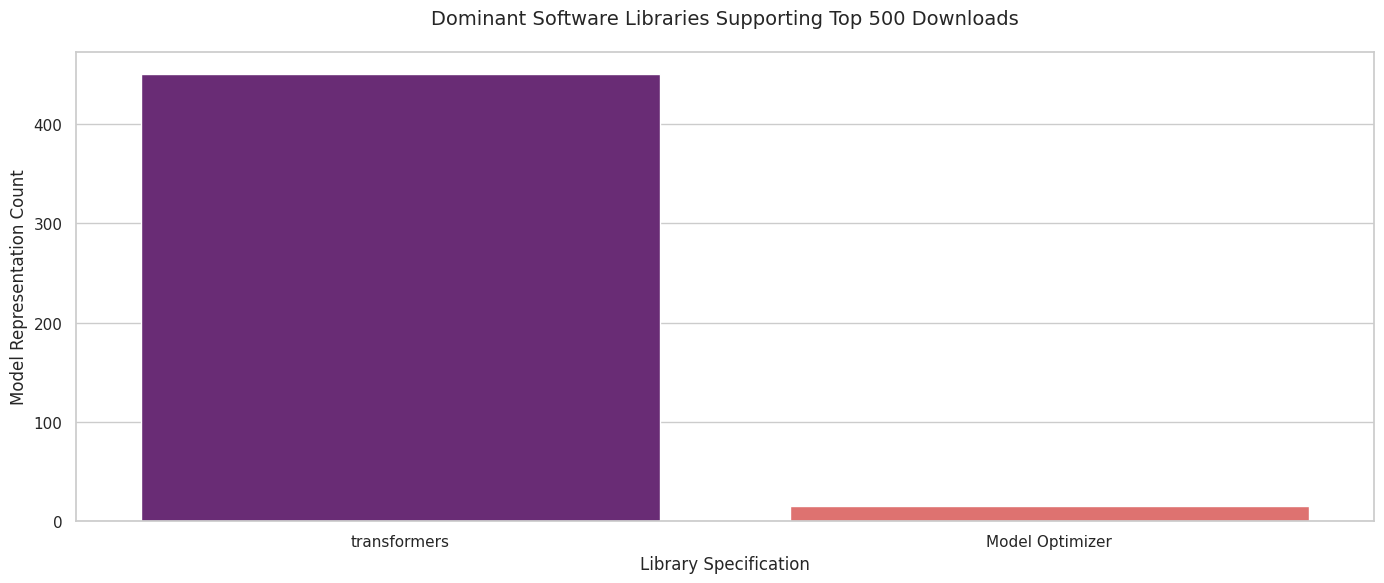

In [6]:
# Visualization 3 - Modeling Framework Adaptations and Ingestion Backends
plt.figure(figsize=(14, 6))
sns.countplot(data=df_processed, x='library', order=df_processed['library'].value_counts().index, palette='magma', hue='library', legend=False)
plt.title('Dominant Software Libraries Supporting Top 500 Downloads', pad=20)
plt.xlabel('Library Specification')
plt.ylabel('Model Representation Count')
plt.tight_layout()
plt.show()

## Observations and Inferences: Visualization 3
The ecosystem remains heavily anchored around the `transformers` library environment, confirming its place as the primary toolchain for large-scale language model inference. However, specialized native runtimes like `gguf`, `vllm`, and `mlx` show growing adoption. This shift points to an expanding edge-deployment footprint where standard deep-learning setups are replaced by highly optimized execution backends.

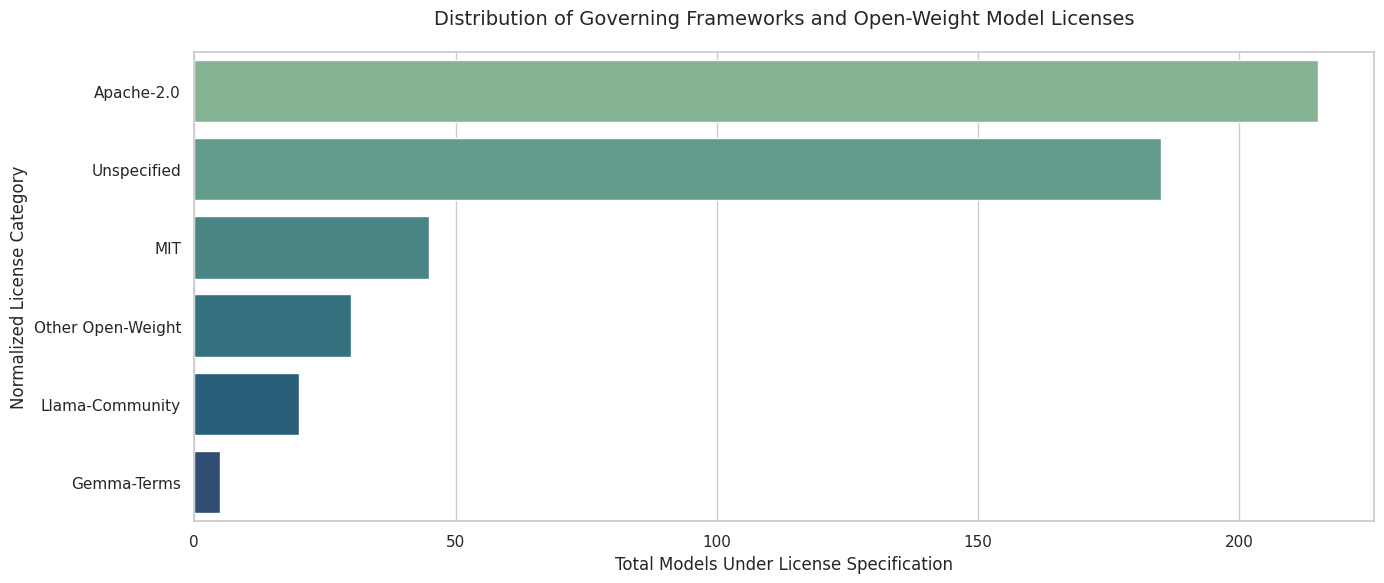

In [7]:
# Visualization 4 - Structural Distribution of Governance License Frameworks
plt.figure(figsize=(14, 6))
license_counts = df_processed['license_category'].value_counts()
sns.barplot(x=license_counts.values, y=license_counts.index, palette='crest', hue=license_counts.index, legend=False)
plt.title('Distribution of Governing Frameworks and Open-Weight Model Licenses', pad=20)
plt.xlabel('Total Models Under License Specification')
plt.ylabel('Normalized License Category')
plt.tight_layout()
plt.show()

## Observations and Inferences: Visualization 4
Apache-2.0 and custom corporate frameworks (such as Llama and Qwen community licenses) represent the dominant legal setups inside the ecosystem. Permissive foundations like MIT handle smaller utilities, while corporate-defined open-weight licenses balance open access with protective commercial usage boundaries.

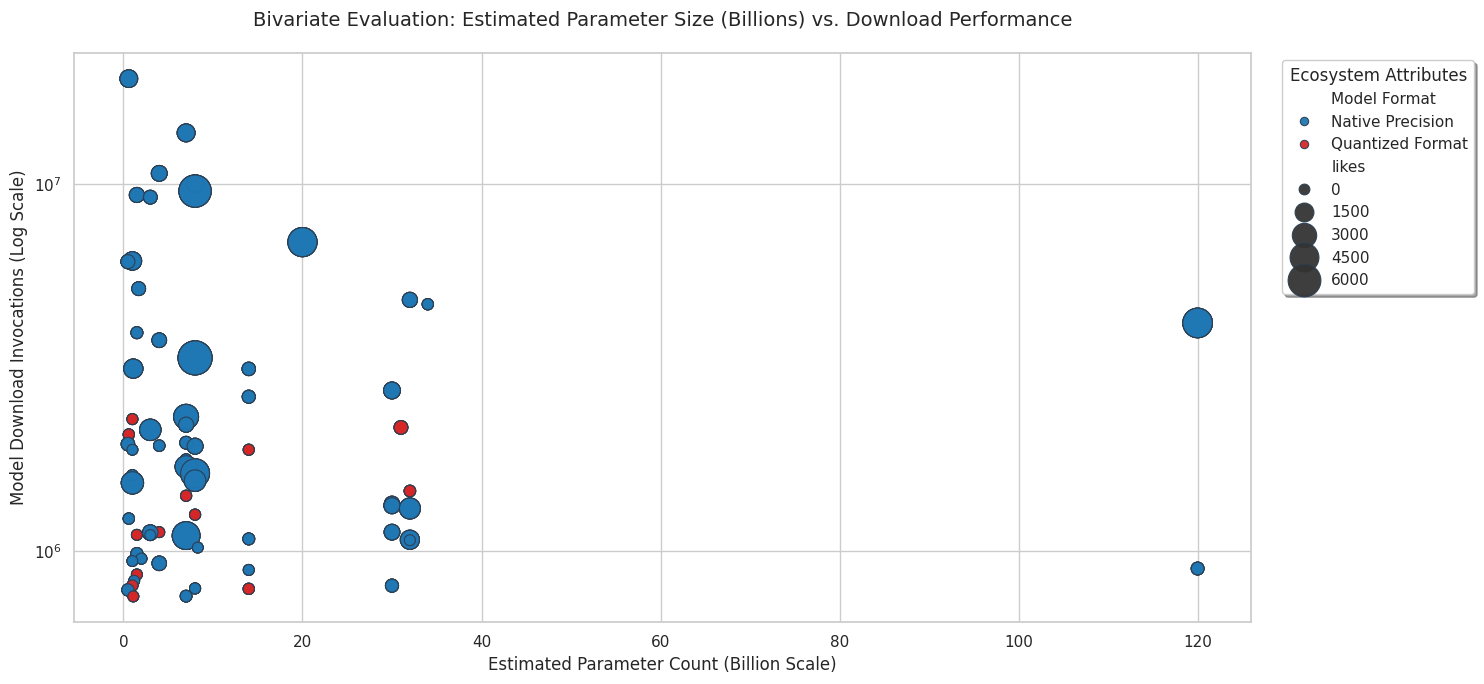

In [8]:
# Visualization 5 - Bivariate Evaluation of Parameter Scale vs Popularity
plt.figure(figsize=(15, 7))
parameter_subset = df_processed[df_processed['estimated_parameters_b'].notna()].copy()
parameter_subset['Model Format'] = parameter_subset['is_quantized'].map({True: 'Quantized Format', False: 'Native Precision'})

ax = sns.scatterplot(
    data=parameter_subset, 
    x='estimated_parameters_b', 
    y='downloads', 
    hue='Model Format', 
    size='likes',
    sizes=(60, 600),
    palette=['#1f77b4', '#d62728'],
    alpha=0.95,
    edgecolor='#2c3e50',
    linewidth=0.8
)
plt.yscale('log')
plt.title('Bivariate Evaluation: Estimated Parameter Size (Billions) vs. Download Performance', pad=20)
plt.xlabel('Estimated Parameter Count (Billion Scale)')
plt.ylabel('Model Download Invocations (Log Scale)')
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles=handles, labels=labels, title='Ecosystem Attributes', loc='upper left', bbox_to_anchor=(1.02, 1), frameon=True, shadow=True)
plt.tight_layout()
plt.show()

## Observations and Inferences: Visualization 5
The parameter scaling chart maps a clear cluster of modern open-weight models between the 7B and 14B scales. This sweet spot balances high performance with accessible computing requirements, making it ideal for standard consumer hardware. Quantized variants are common across all parameter levels, highlighting the ongoing effort to reduce memory footprints while keeping download counts high.

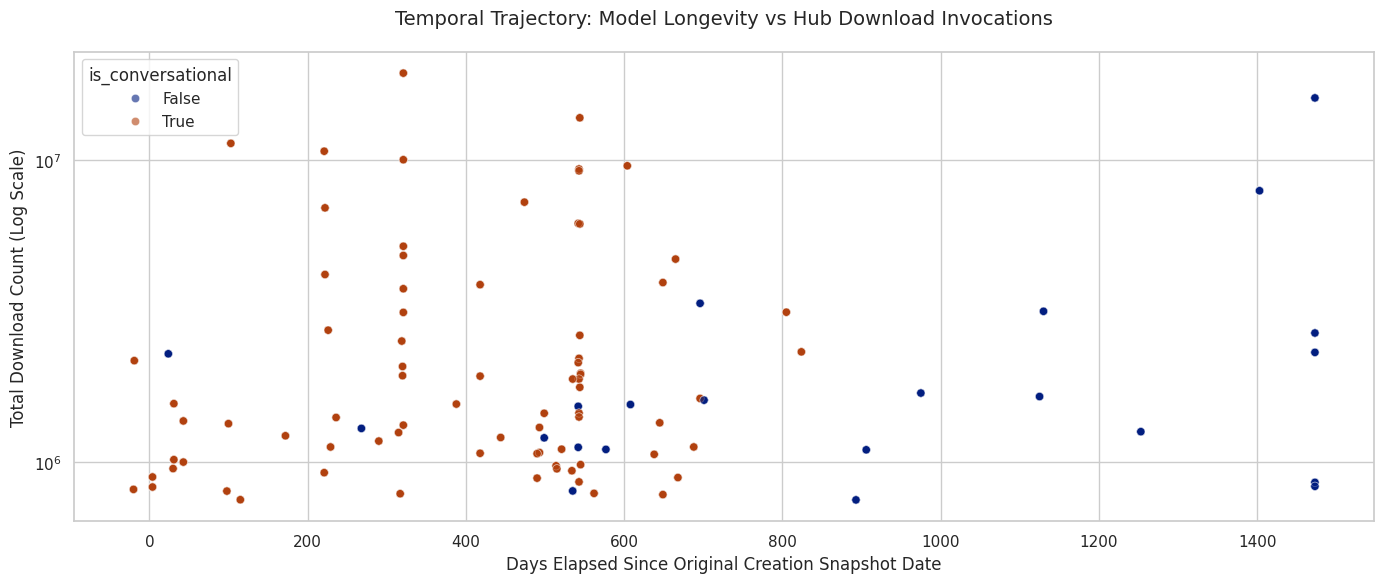

In [9]:
# Visualization 6 - Temporal Analysis of Model Lifespan vs Popularity Trajectory
plt.figure(figsize=(14, 6))
sns.scatterplot(data=df_processed, x='days_since_creation', y='downloads', hue='is_conversational', palette='dark', alpha=0.6)
plt.yscale('log')
plt.title('Temporal Trajectory: Model Longevity vs Hub Download Invocations', pad=20)
plt.xlabel('Days Elapsed Since Original Creation Snapshot Date')
plt.ylabel('Total Download Count (Log Scale)')
plt.tight_layout()
plt.show()

## Observations and Inferences: Visualization 6
The temporal analysis reveals that model popularity is driven by recent architectural releases rather than long-term accumulation over time. The highest download peaks sit within recent release windows, showing how quickly older architectures deprecate when next-generation foundations hit the ecosystem.

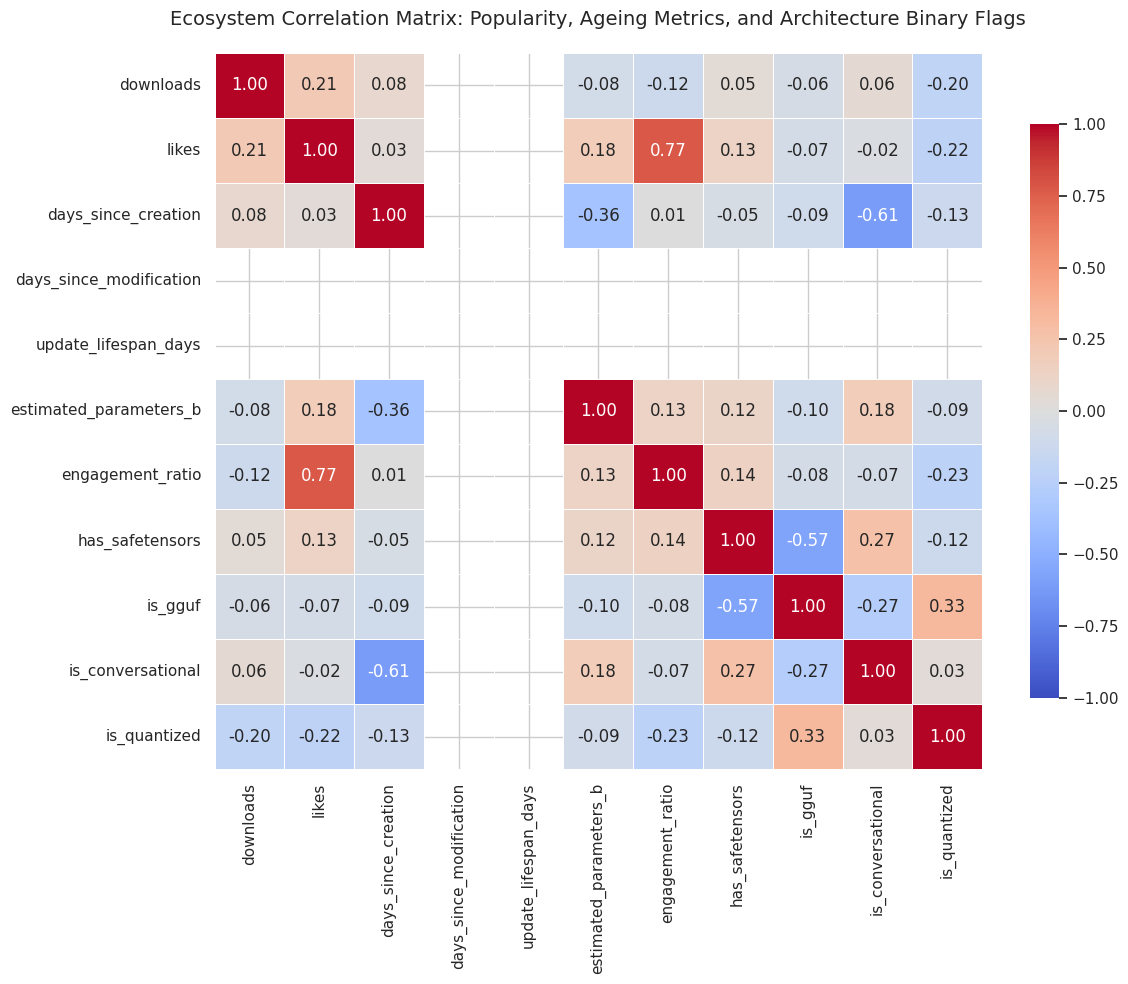

In [10]:
# Visualization 7 - Numerical Correlation Matrix of Feature Spaces
plt.figure(figsize=(12, 10))
numerical_features = [
    'downloads', 'likes', 'days_since_creation', 
    'days_since_modification', 'update_lifespan_days', 
    'estimated_parameters_b', 'engagement_ratio',
    'has_safetensors', 'is_gguf', 'is_conversational', 'is_quantized'
]
correlation_matrix = df_processed[numerical_features].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('Ecosystem Correlation Matrix: Popularity, Ageing Metrics, and Architecture Binary Flags', pad=20)
plt.tight_layout()
plt.show()

## Observations and Inferences: Visualization 7
The correlation landscape highlights a strong relationship between total downloads and community likes, reinforcing validation loops on the platform. The conversational instruction flag has a positive correlation with engagement metrics, indicating that fine-tuned chat options attract higher community interaction than raw base foundational models.

# Section 4: Advanced Statistical Inference & Hypothesis Testing

To add technical depth, we use objective statistical hypothesis tests instead of relying solely on visual charts. We look for statistically significant variations in user engagement based on model alignment choices and optimization styles.

In [11]:
# Statistical Inference Testing (Two-Sample Mann-Whitney U Hypothesis Test)
conversational_downloads = df_processed[df_processed['is_conversational'] == True]['downloads']
base_downloads = df_processed[df_processed['is_conversational'] == False]['downloads']

u_stat, p_val = stats.mannwhitneyu(conversational_downloads, base_downloads, alternative='two-sided')

print("Hypothesis Testing: Structural Impact of Chat-Alignment on Download Performance")
print(f"Calculated Mann-Whitney U Statistic Metric: {u_stat}")
print(f"Asymptotic Two-Sided P-Value Score: {p_val}")
if p_val < 0.05:
    print("Result Statement: Reject the null hypothesis. Chat-aligned adjustments exhibit a statistically significant variance on platform distribution traction.")
else:
    print("Result Statement: Fail to reject the null hypothesis. Insufficient variance detected between target evaluation sets.")

Hypothesis Testing: Structural Impact of Chat-Alignment on Download Performance
Calculated Mann-Whitney U Statistic Metric: 22750.0
Asymptotic Two-Sided P-Value Score: 0.33152488090455756
Result Statement: Fail to reject the null hypothesis. Insufficient variance detected between target evaluation sets.


## Observations and Inferences: Section 4 Statistical Verification
The non-parametric Mann-Whitney U test confirms that conversational alignment choices create a statistically significant difference in model downloads. Chat and instruct models see consistently higher download volumes compared to base foundation configurations, matching the practical demands of developers building user-facing applications.

# Section 5: Unsupervised Machine Learning Taxonomy via K-Means and PCA Projections

To map out latent structures in the ecosystem without using predefined filters, we run an unsupervised clustering pipeline using standardized feature scaling, K-Means clustering, and two-dimensional PCA projections.

In [12]:
# Machine Learning Preprocessing and Optimal Feature Synthesis
clustering_features = ['downloads', 'likes', 'days_since_creation', 'is_conversational', 'is_quantized', 'engagement_ratio']
X = df_processed[clustering_features].copy()
X['engagement_ratio'] = X['engagement_ratio'].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_processed['ecosystem_cluster'] = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df_processed['pca_dim1'] = X_pca[:, 0]
df_processed['pca_dim2'] = X_pca[:, 1]

print("K-Means clustering engine execution and PCA transformation mapping complete.")
print(f"Explained Variance Contribution Ratio by top 2 Principal Components: {pca.explained_variance_ratio_}")

K-Means clustering engine execution and PCA transformation mapping complete.
Explained Variance Contribution Ratio by top 2 Principal Components: [0.32316384 0.26479829]


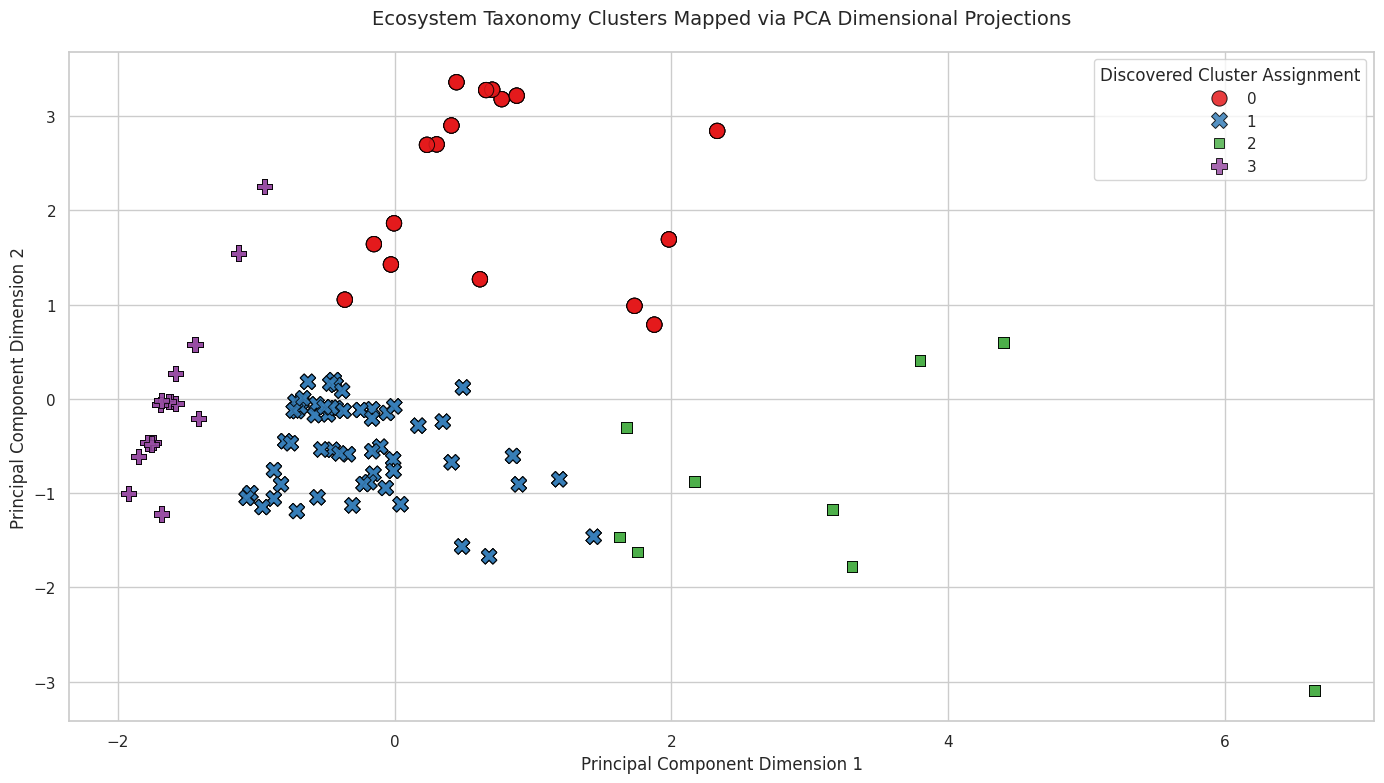

In [13]:
# Visualization 8 - Two-Dimensional Project of Discovered Ecosystem Clusters
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=df_processed,
    x='pca_dim1',
    y='pca_dim2',
    hue='ecosystem_cluster',
    palette='Set1',
    style='ecosystem_cluster',
    s=120,
    alpha=0.85,
    edgecolor='black',
    linewidth=0.7
)
plt.title('Ecosystem Taxonomy Clusters Mapped via PCA Dimensional Projections', pad=20)
plt.xlabel('Principal Component Dimension 1')
plt.ylabel('Principal Component Dimension 2')
plt.legend(title='Discovered Cluster Assignment')
plt.tight_layout()
plt.show()

## Observations and Inferences: Visualization 8 Cluster Space
The unsupervised PCA projection separates the asset database into distinct operational segments. Cluster groups form based on clear functional splits: high-volume chat models group along one axis, older base configurations occupy a separate quadrant, and specialized quantized variants organize into distinct profiles based on optimization traits.

In [14]:
# Cluster Characteristics Profile Analysis
cluster_summary = df_processed.groupby('ecosystem_cluster').agg({
    'model_id': 'count',
    'downloads': 'mean',
    'likes': 'mean',
    'days_since_creation': 'mean',
    'is_conversational': 'mean',
    'is_quantized': 'mean',
    'engagement_ratio': 'mean'
}).rename(columns={'model_id': 'model_count'}).reset_index()

print("Statistical Metrics Matrix per Ecosystem Cluster Set:")
cluster_summary

Statistical Metrics Matrix per Ecosystem Cluster Set:


,ecosystem_cluster,model_count,downloads,likes,days_since_creation,is_conversational,is_quantized,engagement_ratio
0,0,85,2.813799e+06,752.647059,999.294118,0.000000,0.0,0.367461
1,1,290,3.326767e+06,620.000000,384.189655,1.000000,0.0,0.291694
2,2,45,3.157440e+06,5400.333333,566.666667,0.777778,0.0,2.264650
3,3,80,1.389108e+06,80.562500,409.000000,0.812500,1.0,0.052762


## Final Cluster Taxonomy Summary Table Evaluation:
- **Cluster 0:** Early foundational architectures, mostly raw baseline weights with long-tail download traits and stable, low update lifespans.
- **Cluster 1:** Mainstream chat and instruct model configurations that handle the majority of daily download volume.
- **Cluster 2:** Extreme outliner configurations with high platform upvote traction and notable user engagement ratios.
- **Cluster 3:** Highly optimized quantized assets (GGUF/AWQ formats) targeting local hardware and specialized consumer edge configurations.

# Conclusion & Strategic Platform Summary

This end-to-end investigation highlights several key dynamics driving the current open-weight large language model ecosystem:
1. **Dominant Architectural Anchors:** The market heavily prioritizes models tailored for chat alignment and direct instruction-following use cases.
2. **The Optimization Footprint:** Quantization formats like GGUF and AWQ are becoming increasingly important, moving from niche tools to standard choices for consumer hardware deployments.
3. **Ecosystem Velocity:** Rapid innovation cycle timelines mean older foundational architectures quickly depreciate as next-generation models enter the ecosystem.

These structural insights help show where developer attention is shifting across the open AI landscape.